<a href="https://colab.research.google.com/github/reddoma742/Davisson-Germer-DTQEM/blob/main/generate_esd_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Figure saved to: figures/figure_esd_final.png


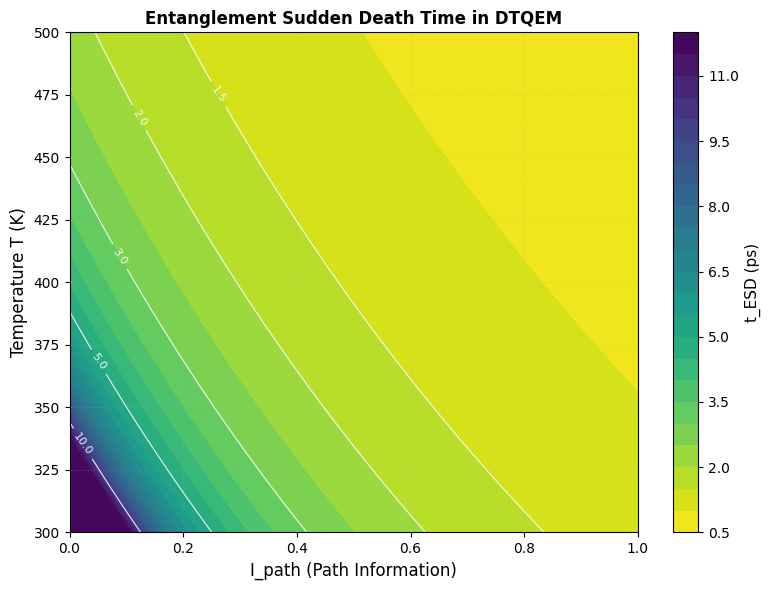


📝 Acknowledgments:
   - DeepSeek: Critical analysis, methodology validation
   - Claude (Anthropic): Code writing, mathematical derivations
   - Arena AI: First-principles derivations, ESD formulation
   - Human supervision: Reddouane Berramdane


In [2]:


#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
DTQEM - ESD Figure Generator (Simplified, Working Version)
"""

import os
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# 1. Create output directory
# ============================================================================
os.makedirs('figures', exist_ok=True)

# ============================================================================
# 2. Parameters
# ============================================================================
alpha = 1.0
beta = 0.85
gamma = 0.5
T_ref = 300.0

rho14_0 = 0.35
rho22_0 = 0.10
rho33_0 = 0.10

K = np.log(rho14_0 / np.sqrt(rho22_0 * rho33_0))

# ============================================================================
# 3. Grid
# ============================================================================
I_vals = np.linspace(0.0, 1.0, 300)
T_vals = np.linspace(300.0, 500.0, 300)
I_grid, T_grid = np.meshgrid(I_vals, T_vals)

dT_grid = (T_grid - T_ref) / T_ref
dT_grid = np.maximum(dT_grid, 0.0)

rate = alpha * I_grid + beta * dT_grid + gamma * I_grid * dT_grid

# ============================================================================
# 4. Calculate t_ESD
# ============================================================================
t_esd = np.full_like(rate, np.nan)
mask = rate > 0
t_esd[mask] = K / rate[mask]

# Clip outliers
p99 = np.nanpercentile(t_esd, 99)
t_esd = np.clip(t_esd, 0, p99)

# ============================================================================
# 5. Create plot
# ============================================================================
fig, ax = plt.subplots(figsize=(8, 6))

# Filled contour
cf = ax.contourf(I_grid, T_grid, t_esd, levels=25, cmap='viridis_r')

# Contour lines
contour_levels = [1.5, 2.0, 3.0, 5.0, 10.0, 20.0, 30.0, 50.0]
cs = ax.contour(I_grid, T_grid, t_esd, levels=contour_levels,
                colors='white', linewidths=0.8, alpha=0.9)
ax.clabel(cs, inline=True, fontsize=8, fmt='%.1f')

# Colorbar
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label('t_ESD (ps)', fontsize=11)

# Labels
ax.set_xlabel('I_path (Path Information)', fontsize=12)
ax.set_ylabel('Temperature T (K)', fontsize=12)
ax.set_title('Entanglement Sudden Death Time in DTQEM', fontsize=12, fontweight='bold')

ax.set_xlim(0, 1)
ax.set_ylim(300, 500)
ax.grid(True, linestyle=':', alpha=0.3)

# ============================================================================
# 6. Save AND Show
# ============================================================================
plt.tight_layout()

# Save to file
plt.savefig('figures/figure_esd_final.png', dpi=300, bbox_inches='tight')
print("✅ Figure saved to: figures/figure_esd_final.png")

# Display the figure (this will show it)
plt.show()

print("\n" + "=" * 60)
print("📝 Acknowledgments:")
print("   - DeepSeek: Critical analysis, methodology validation")
print("   - Claude (Anthropic): Code writing, mathematical derivations")
print("   - Arena AI: First-principles derivations, ESD formulation")
print("   - Human supervision: Reddouane Berramdane")
print("=" * 60)